# Linear Regression Implementation

In [1]:
import numpy as np

In [2]:
# Initialize Model Parameters
def initialize_params(dims: int):
    '''
    Inputs:
    dims: Number of features (dimensions)

    Outputs:
    w: Initialized weight vector (dims, 1)
    b: Initialized bias scalar
    '''
    # Initialize weights to zeros
    w = np.zeros((dims, 1))
    # Initialize bias to zero
    b = 0
    return w, b

In [3]:
# Define Model Core
def linear_loss(X: np.ndarray, y: np.ndarray, w: np.ndarray, b: float):
    '''
    Inputs:
    X: Input feature matrix (num_samples, num_features)
    y: Output label vector (num_samples, 1)
    w: Weight parameters (num_features, 1)
    b: Bias parameter

    Outputs:
    y_hat: Linear model prediction
    loss: Mean Squared Error (MSE)
    dw: Gradient of weights
    db: Gradient of bias
    '''
    # Number of training samples
    num_train = X.shape[0]

    # Linear prediction: y = Xw + b
    y_hat = np.dot(X, w) + b

    # Compute Loss: (1/2m) * sum((y_hat - y)^2)
    # Note: Using 1/2m makes the derivative cleaner (cancels out the square power)
    loss = np.sum((y_hat - y) ** 2) / (2 * num_train)

    # Compute gradients (partial derivatives)
    # dw = (1/m) * X.T * (y_hat - y)
    dw = np.dot(X.T, (y_hat - y)) / num_train
    # db = (1/m) * sum(y_hat - y)
    db = np.sum((y_hat - y)) / num_train

    return y_hat, loss, dw, db

In [4]:
# Define Training Process
def linear_train(X: np.ndarray, y: np.ndarray, learning_rate: float = 0.01, epochs: int = 10000):
    '''
    Inputs:
    X: Training inputs
    y: Training labels
    learning_rate: Step size for gradient descent
    epochs: Number of iterations

    Outputs:
    loss_his: History of loss values
    params: Dictionary containing optimized 'w' and 'b'
    grads: Dictionary containing final gradients
    '''
    loss_his = []

    # Initialize parameters
    w, b = initialize_params(X.shape[1])

    # Iterative Training
    for i in range(1, epochs + 1):
        # Forward pass & Gradient calculation
        y_hat, loss, dw, db = linear_loss(X, y, w, b)

        # Gradient Descent Update
        w += -learning_rate * dw
        b += -learning_rate * db

        # Record loss
        loss_his.append(loss)

        # Print loss every 10,000 epochs
        if i % 10000 == 0:
            print('epoch %d loss %f' % (i, loss))

        # Save current parameters and gradients
        params = {'w': w, 'b': b}
        grads = {'dw': dw, 'db': db}

    return loss_his, params, grads

In [5]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
data = diabetes.data
target = diabetes.target
print(data.shape)
print('=' * 20)
print(target.shape)
print('=' * 20)
print(data[:5])
print('=' * 20)
print(target[:5])

(442, 10)
(442,)
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
[151.  75. 141. 206. 135.]


In [6]:
# Import helpers from sklearn
from sklearn.datasets import load_diabetes
from sklearn.utils import shuffle

# Load diabetes dataset
diabetes = load_diabetes()
data, target = diabetes.data, diabetes.target

# Shuffle randomizes the data
X, y = shuffle(data, target, random_state=42)

# Split into Train (80%) and Test (20%)
offset = int(X.shape[0] * 0.8)
X_train, y_train = X[:offset], y[:offset]
X_test, y_test = X[offset:], y[offset:]

# Reshape labels to column vectors (n, 1)
y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

# Print shapes
print("X_train's shape: ", X_train.shape)
print("X_test's shape: ", X_test.shape)
print("y_train's shape: ", y_train.shape)
print("y_test's shape: ", y_test.shape)

X_train's shape:  (353, 10)
X_test's shape:  (89, 10)
y_train's shape:  (353, 1)
y_test's shape:  (89, 1)


In [7]:
# Train Model
loss_his, params, grads = linear_train(X_train, y_train, 0.01, 200000)
# Print optimized parameters
print(params)

epoch 10000 loss 1930.520204
epoch 20000 loss 1658.251904
epoch 30000 loss 1548.644345
epoch 40000 loss 1490.119281
epoch 50000 loss 1455.230805
epoch 60000 loss 1433.565623
epoch 70000 loss 1419.824238
epoch 80000 loss 1410.965761
epoch 90000 loss 1405.167048
epoch 100000 loss 1401.312033
epoch 110000 loss 1398.707532
epoch 120000 loss 1396.917562
epoch 130000 loss 1395.664643
epoch 140000 loss 1394.770140
epoch 150000 loss 1394.117750
epoch 160000 loss 1393.630910
epoch 170000 loss 1393.258656
epoch 180000 loss 1392.966687
epoch 190000 loss 1392.731657
epoch 200000 loss 1392.537499
{'w': array([[   6.18254431],
       [-232.77534182],
       [ 508.87803824],
       [ 275.0549077 ],
       [ -74.59679636],
       [-121.46136179],
       [-225.82522309],
       [ 126.89229224],
       [ 496.40692652],
       [  97.08705859]]), 'b': np.float64(153.99443853502402)}


In [8]:
### Define Prediction Function
def predict(X: np.ndarray, params: dict):
    '''
    Inputs:
    X: Test data
    params: Trained model parameters (w, b)

    Outputs:
    y_pred: Predicted values
    '''
    w = params['w']
    b = params['b']
    y_pred = np.dot(X, w) + b
    return y_pred

# Make predictions on test set
y_pred = predict(X_test, params)
# Show first 5 predictions
y_pred[:5]

array([[211.70037491],
       [149.52479746],
       [153.42246304],
       [254.54188038],
       [278.20006754]])

In [9]:
print(y_test[:5])

[[202.]
 [ 73.]
 [ 85.]
 [275.]
 [243.]]


In [10]:
### Define R-Squared (R2) Metric
def r2_score(y_test: np.ndarray, y_pred: np.ndarray):
    '''
    Inputs:
    y_test: True labels
    y_pred: Predicted labels

    Outputs:
    r2: R-squared coefficient
    '''
    # Mean of true labels
    y_avg = np.mean(y_test)

    # Total Sum of Squares (TSS)
    ss_tot = np.sum((y_test - y_avg) ** 2)

    # Residual Sum of Squares (RSS)
    ss_res = np.sum((y_test - y_pred) ** 2)

    # R2 formula
    r2 = 1 - (ss_res / ss_tot)
    return r2

In [11]:
print(r2_score(y_test, y_pred))

0.4045185172355664


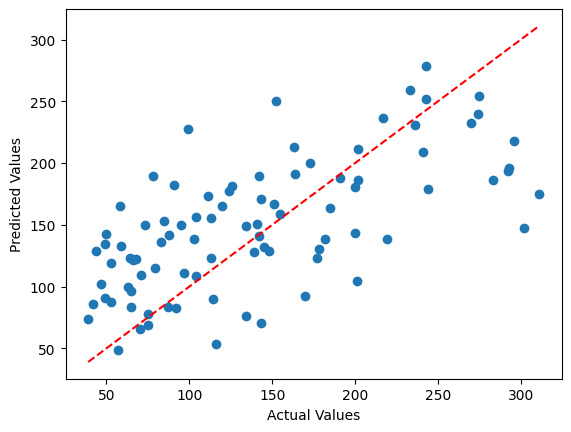

In [12]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

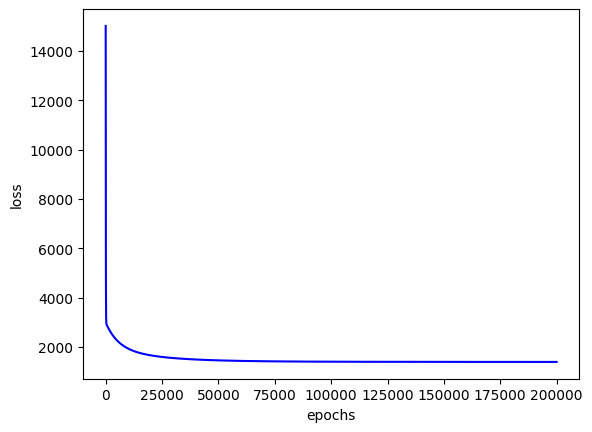

In [13]:
plt.plot(loss_his, color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [14]:
### Compare with scikit-learn
# Import sklearn Linear Regression
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Create model
regr = linear_model.LinearRegression()

# Fit
regr.fit(X_train, y_train)

# Predict
y_pred_sklearn = regr.predict(X_test)

# Print MSE
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_sklearn))
# Print R2 Score
print('R2 score: %.2f' % r2_score(y_test, y_pred_sklearn))

Mean squared error: 3368.04
R2 score: 0.40
